In [1]:
# Setup: Add parent directory to Python path to import beaversim modules# Apply Gaussian blur to all images (increase/decrease sigma for stronger/weaker smoothing)
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'beaversim').is_dir():
        project_root = parent
        break
else:
    raise RuntimeError("Could not locate project root containing 'beaversim'.")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root: {project_root}")
print(f"Python path updated to include: {project_root}")

Project root: /home/fedeoli/Documents/Projects/BeaverSim
Python path updated to include: /home/fedeoli/Documents/Projects/BeaverSim


In [6]:
from pathlib import Path
from beaversim.ral.backend.beavers_visualizer_backend import BeaversVisualizerBackend

# Define folder and file name for a saved backend pickle
backend_dir = Path("../../output/simulations/rumney_ranch_demo/hydrological_expansion/REV_4_agents_4_years_eta_099_perc_rep_quality_02/montecarlo/seed_1").resolve()
backend_file = "final_backend.pkl.gz"
backend_path = backend_dir / backend_file

if not backend_path.exists():
    raise FileNotFoundError(f"Backend pickle not found: {backend_path.resolve()}")

back = BeaversVisualizerBackend.load_backend_pickle(str(backend_path))
print(f"Loaded backend from: {backend_path.resolve()}")

Loaded backend from: /home/fedeoli/Documents/Projects/BeaverSim/output/simulations/rumney_ranch_demo/hydrological_expansion/REV_4_agents_4_years_eta_099_perc_rep_quality_02/montecarlo/seed_1/final_backend.pkl.gz


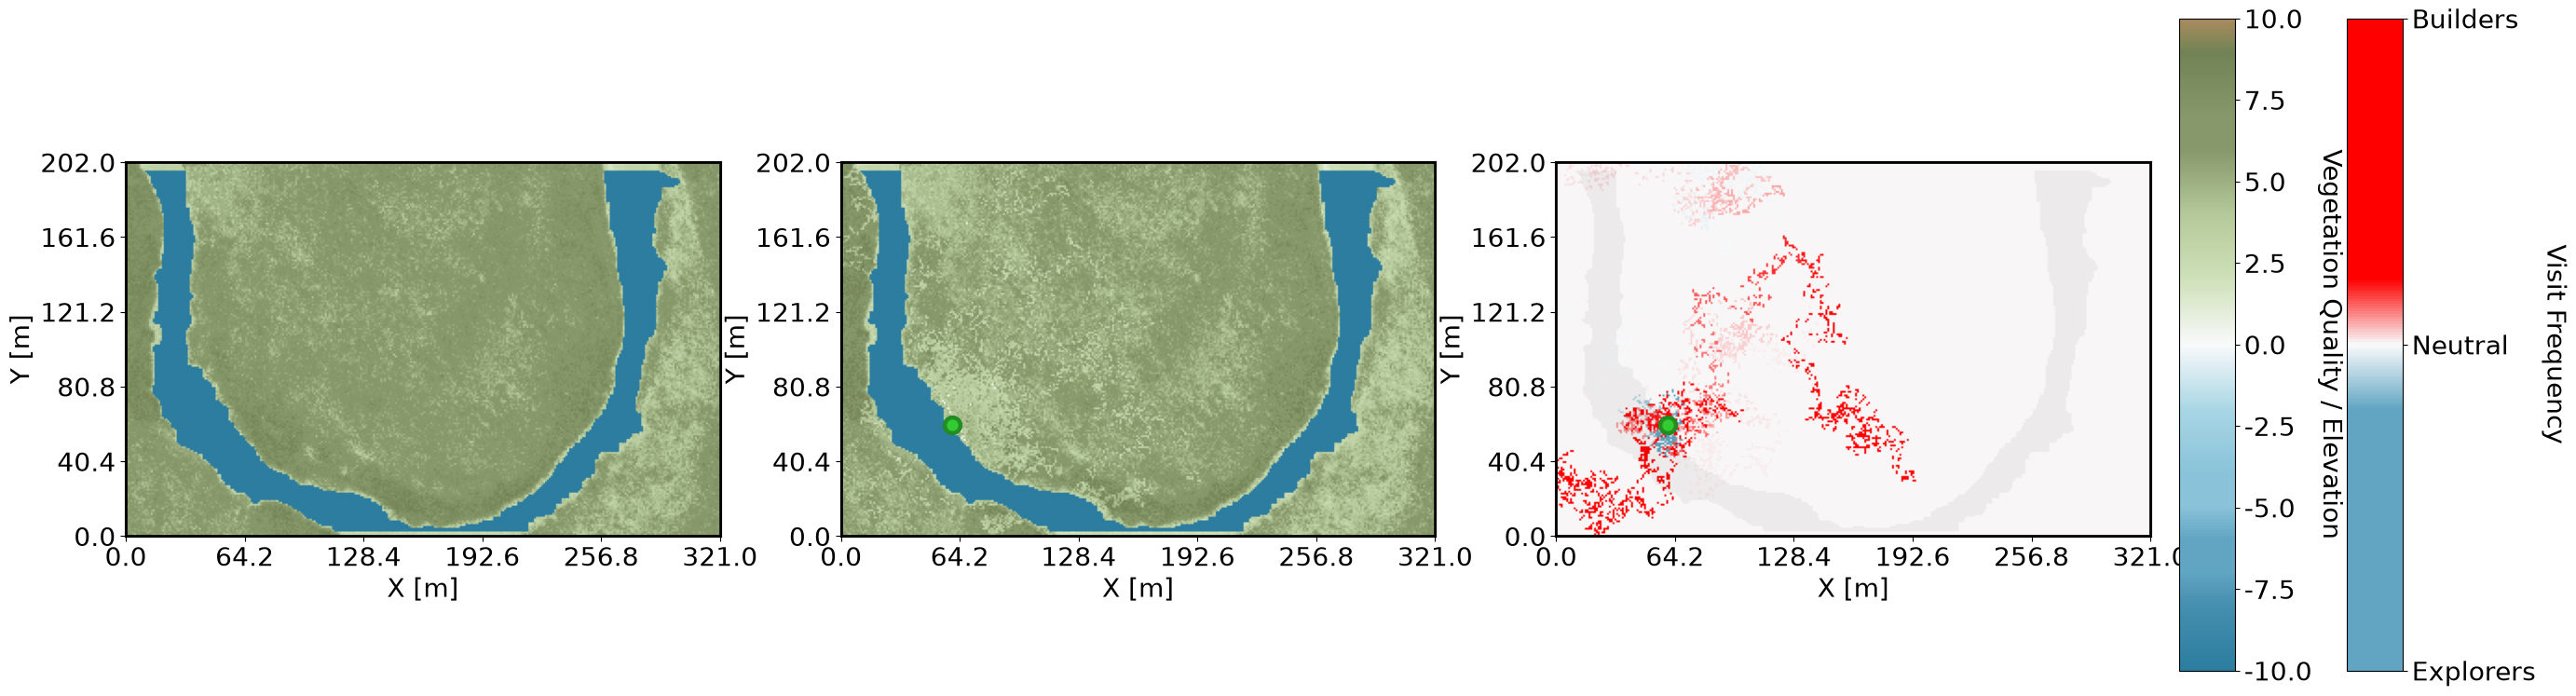

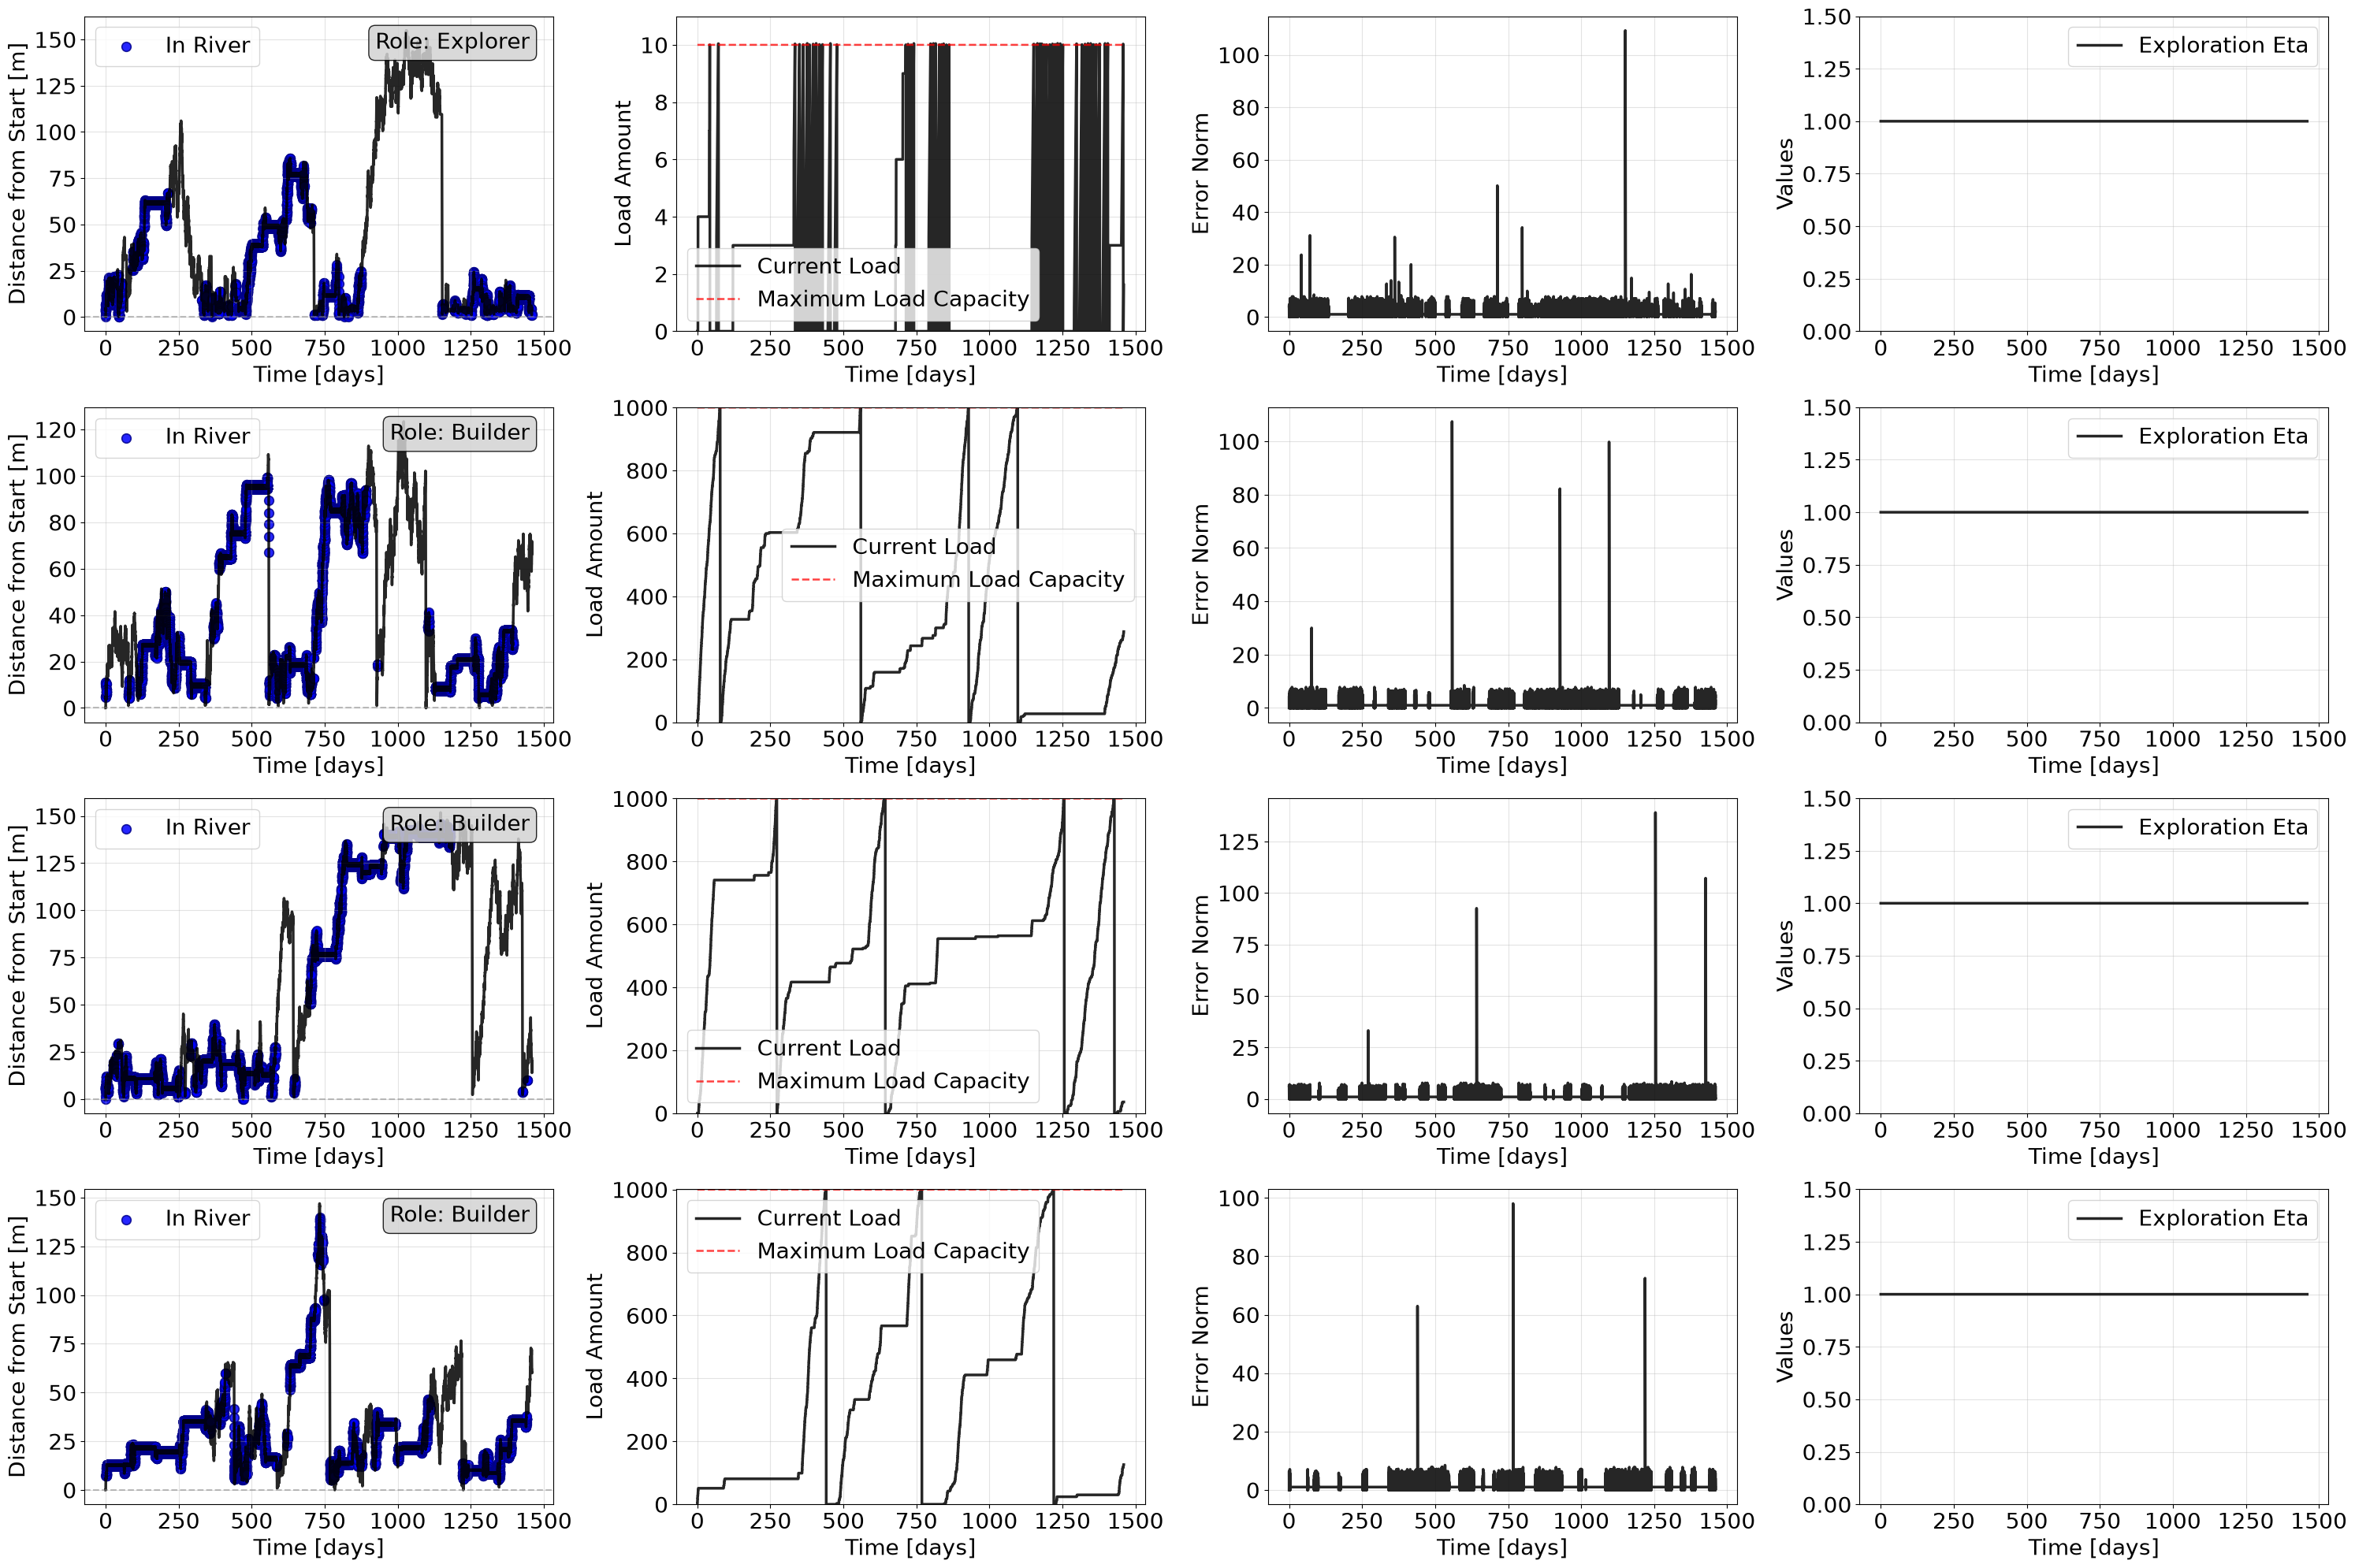

In [7]:
back.plot_environment_with_heatmap(
    plot_agents=False, 
    plot_visit_markers=False, 
    plot_agent_trajectories=False,
    plot_motion_destination=False,
)    
back.plot_simulation_recap()

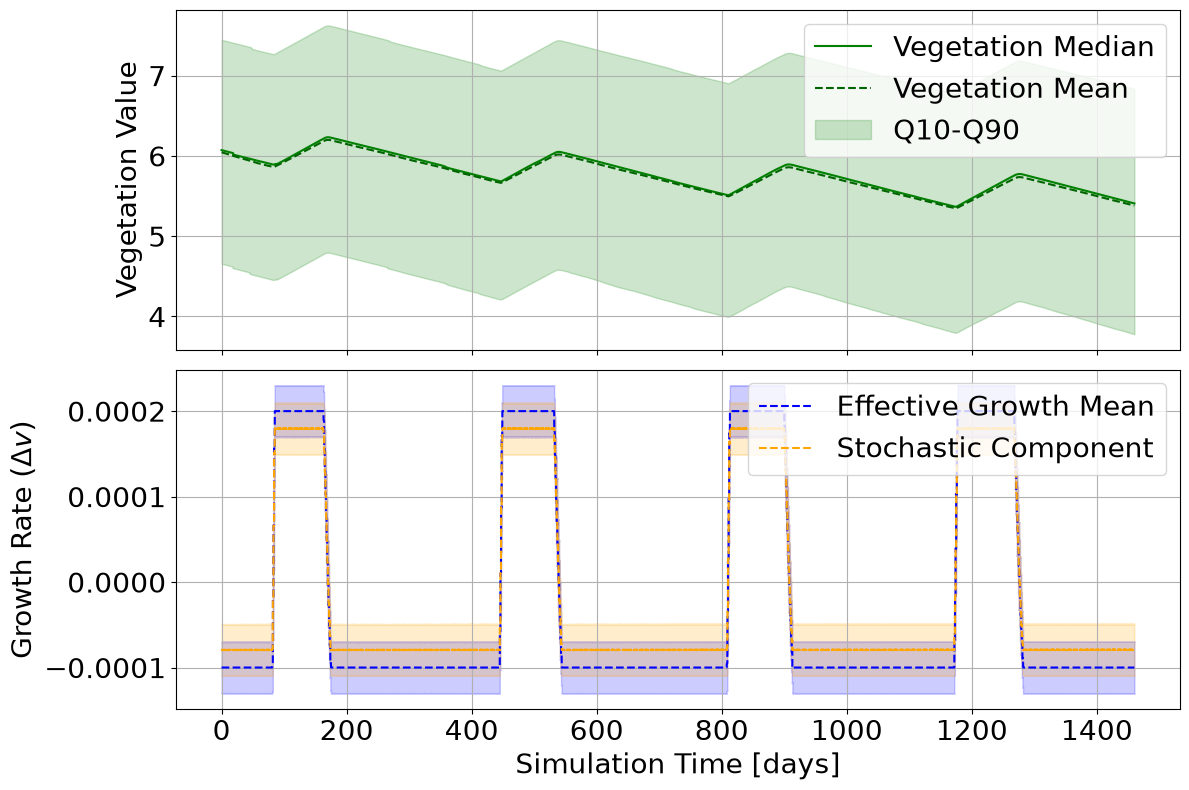

In [8]:
from beaversim.ral.backend.modules.beavers_plotting import plot_growth_statistics
plot_growth_statistics(back)

In [ ]:
import importlib
from pathlib import Path
from beaversim.ral.backend.modules import beavers_plotting

importlib.reload(beavers_plotting)

# Check for maps and visits in separate subdirectories
maps_dir = backend_dir / 'maps'
visits_dir = backend_dir / 'visits'

maps_files = sorted(maps_dir.glob('*.npy')) if maps_dir.exists() else []
visits_files = sorted(visits_dir.glob('*.npy')) if visits_dir.exists() else []

if not maps_files:
    raise FileNotFoundError(f"No .npy files found in {maps_dir}")
if not visits_files:
    raise FileNotFoundError(f"No .npy files found in {visits_dir}")

snapshot_numbers = [1, 4, 7, 10, 13]  # 1-based positions in the sorted .npy list
max_snapshots = min(len(maps_files), len(visits_files))
valid_snapshot_numbers = [n for n in snapshot_numbers if 1 <= n <= max_snapshots]

print(f'Maps directory: {maps_dir} ({len(maps_files)} files found)')
print(f'Visits directory: {visits_dir} ({len(visits_files)} files found)')
print(f'Requested: {snapshot_numbers} | Valid: {valid_snapshot_numbers}')

if valid_snapshot_numbers:
    beavers_plotting.plot_spatial_snapshots_by_number(
        backend=back,
        snapshot_dir=str(backend_dir),
        snapshot_numbers=valid_snapshot_numbers,
        one_indexed=True,
        show_titles=True
    )
else:
    print('No valid snapshot numbers for the resolved folders.')

In [ ]:
import importlib
from pathlib import Path
from beaversim.ral.backend.modules import beavers_plotting

importlib.reload(beavers_plotting)

# Compare two generic vegetation matrices using backend grid/resolution.
real_data_npy = project_root / 'output/RumneyRanch_Montana/RGB/A2/raw/A2_10_final_matrix.npy'
simulation_npy = project_root / 'output/simulations/rumney_ranch_demo/final_test_4agents/maps/map_0006.npy'

# Discard the returned Figure so the notebook does not render it a second time.
_ = beavers_plotting.plot_two_vegetation_npy_with_backend_grid(
    backend=back,
    real_npy_path=real_data_npy,
    sim_npy_path=simulation_npy,
)

In [ ]:
from beaversim.ral.backend.modules.beavers_plotting import plot_agent_motion_diagnostics

environment = getattr(back, '_environment', None)
resolution_m = getattr(environment, '_resolution_m', 1.0)
try:
    resolution_m = float(resolution_m)
except (TypeError, ValueError):
    resolution_m = 1.0
if resolution_m <= 0:
    resolution_m = 1.0

# Retrieve controller accuracy directly from the loaded backend state (no external config needed).
accuracy_px = None
schedule = getattr(back, '_schedule', None)
agents = list(getattr(schedule, 'agents', [])) if schedule is not None else []

if agents:
    first_agent = agents[0]

    for attr_name in ('_accuracy', 'accuracy'):
        if hasattr(first_agent, attr_name):
            value = getattr(first_agent, attr_name)
            if value is not None:
                accuracy_px = value
                break

    if accuracy_px is None and hasattr(first_agent, '_controller'):
        controller = getattr(first_agent, '_controller')
        for attr_name in ('_accuracy', 'accuracy'):
            if hasattr(controller, attr_name):
                value = getattr(controller, attr_name)
                if value is not None:
                    accuracy_px = value
                    break

accuracy_m = None
if accuracy_px is not None:
    try:
        accuracy_m = float(accuracy_px) * resolution_m
    except (TypeError, ValueError):
        accuracy_m = None

plot_agent_motion_diagnostics(back, accuracy_m=accuracy_m)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

stats = getattr(back._environment, '_plotting_stats', None)
if not stats:
    raise ValueError('No plotting stats found on back.')

series_order = [
    ('water_pixel_count', 'Water pixel count'), 
    ('land_pixel_count', 'Land pixel count'),
    ('trail_pixel_count', 'Trail pixel count'),
    ('water_pixel_density', 'Water pixel density'),
    ('land_pixel_density', 'Land pixel density'),
    ('trail_pixel_density', 'Trail pixel density'),
]

lengths = [len(stats.get(key, [])) for key, _ in series_order]
if not any(lengths):
    raise ValueError('Plotting stats are empty. Run the simulation first so the backend can collect them.')

steps = np.arange(1, max(lengths) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()

colors = {
    'water_pixel_count': '#1f77b4',
    'water_pixel_density': '#1f77b4',
    'land_pixel_count': '#2ca02c',
    'land_pixel_density': '#2ca02c',
    'trail_pixel_count': '#ff7f0e',
    'trail_pixel_density': '#ff7f0e',
}

for ax, (key, title) in zip(axes, series_order):
    values = np.asarray(stats.get(key, []), dtype=float)
    if values.size == 0:
        ax.set_visible(False)
        continue
    x = np.arange(1, values.size + 1)
    ax.plot(x, values, color=colors[key], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Count')
axes[3].set_ylabel('Density')

for ax in axes:
    if ax.get_visible():
        ax.margins(x=0.02)

fig.suptitle('Time Evolution of Backend Plotting Stats', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()